In [1]:
import numpy as np
import sys
import muram as mio  
import matplotlib.pyplot as plt

In [16]:
# For the SSD data with ch and corona - you can use this path:
pathsource = '/dat/milic/MURaM_enhanced_network/'
# This is enhanced network simulation from Przybylski 2022 (or something like that), and what you need to have for the use is 
# dx = dy = 24 km 
# dz = 20 km
# All the other quantities are self-explanatory, except for B units and orientation of the axis. See below after loading the data.
path3D = pathsource
# There is only one snapshow and its number is 499000
snap_number = 499000


In [3]:
#pathsource = '/dat/milic/'
#path3D = pathsource + '3D/3D_full_subdomain'
#path2D = pathsource #+ '2D/'

In [3]:
# For the other SSD data, with higher resolution and photospher only, use this path:
#pathsource = '/dat/milic/'
#path3D = pathsource + '3D/3D_full_subdomain/' # Sorry I was rearranging something there
#path2D = pathsource + '2D/'

In [17]:
# IF you used the first one, it's FULL snaps - so use MuramSnap
cube = mio.MuramSnap(pathsource, snap_number)
# But for the other one, they are so called SUBSNAPS - so you use MuramSubSnap
#cube = mio.MuramSubSnap(path3D, 0)
cube.available

['rho',
 'vx',
 'vy',
 'vz',
 'eint',
 'Bx',
 'By',
 'Bz',
 'sflx',
 'Temp',
 'Pres',
 'ne',
 'tau']

In [ ]:
cube.Temp.shape
# This means NZ, NX, NY - so the axis are transposed 
# you need to transpose them back as T = cube.Temp.transpose(1,2,0)

# BUT the same way these are transposed, meaning of vector components is also tranposed:
# So Bx in the cube is Bz in the real life, etc.
# And same for V_x

(800, 1024, 1024)

In [ ]:
# The easiest way to look for log tau = 0 layer is: 
tau_mean = np.mean(cube.tau, axis=(1,2))
tau_zero_index = np.argmin(np.abs(tau_mean - 1))
print(f"Index of log tau = 0 layer: {tau_zero_index}")

In [9]:
Tmean = np.mean(cube.Temp, axis=(1,2))

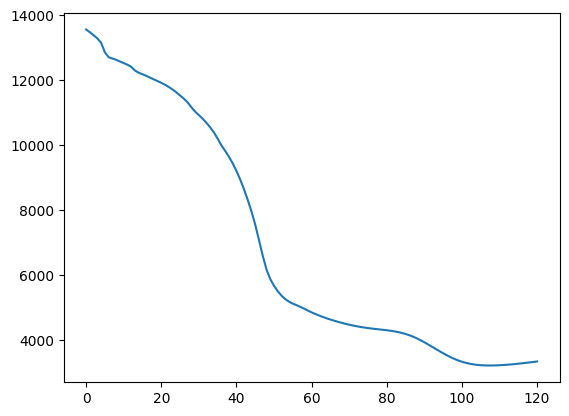

In [10]:
plt.plot(Tmean)
#plt.xlim([0,150])
#plt.ylim([0,10000])

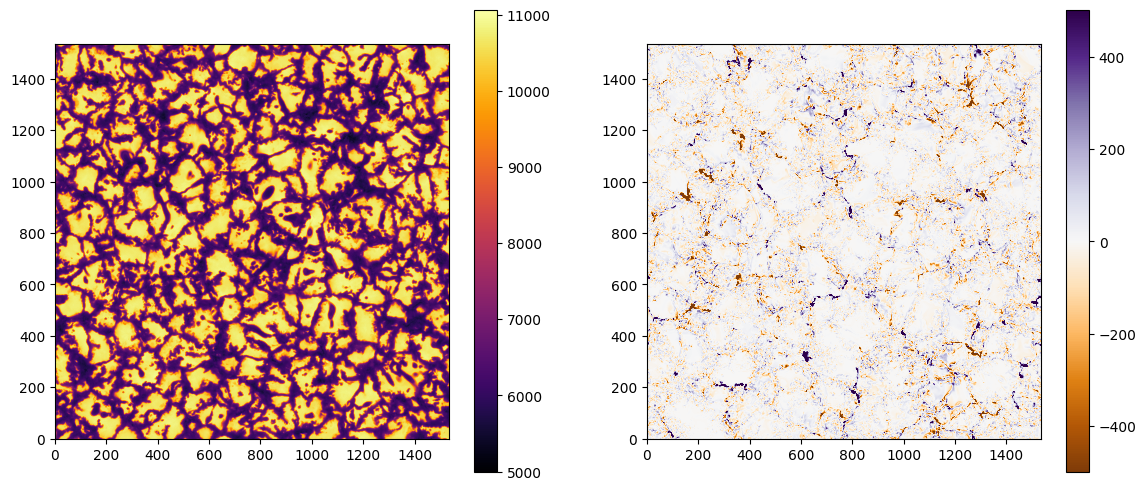

In [13]:
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.imshow(cube.Temp[43,:,:].T, origin='lower', cmap='inferno')
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(cube.Bx[43,:,:].T*np.sqrt(4.0*np.pi), origin='lower', cmap='PuOr', vmin=-500, vmax=500)
plt.colorbar()

In [ ]:
plt.figure(figsize=(16.5,5))
plt.subplot(1,3,1)
plt.imshow(cube.Bx[23,:,:].T*np.sqrt(4.0*np.pi), origin='lower', cmap='PuOr', vmin=-500, vmax=500)
plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(cube.Bx[43,:,:].T*np.sqrt(4.0*np.pi), origin='lower', cmap='PuOr', vmin=-500, vmax=500)
plt.colorbar()
plt.subplot(1,3,3)
plt.imshow(cube.Bx[63,:,:].T*np.sqrt(4.0*np.pi), origin='lower', cmap='PuOr', vmin=-500, vmax=500)
plt.colorbar()



In [15]:
B_mean = np.mean(np.abs(cube.Bx), axis=(1,2))*np.sqrt(4.0*np.pi)
print(B_mean)

[143.96153   142.71472   141.57935   140.46986   139.32144   138.21944
 136.96582   135.74925   134.60582   133.50137   132.1781    130.87102
 129.5069    128.09802   126.544365  124.966545  123.34543   121.697784
 119.92601   118.168015  116.586     115.07098   113.44587   111.79069
 110.22386   108.62198   106.97753   105.29312   103.67646   102.08715
 100.396774   98.644485   96.98799    95.2936     93.54036    91.687035
  89.91418    88.14373    86.36934    84.48656    82.5189     80.40358
  78.16449    75.68492    72.97032    69.889336   66.45089    62.767353
  58.9566     55.161686   51.434406   47.87972    44.54817    41.47564
  38.62425    35.972816   33.549385   31.387344   29.440752   27.705038
  26.186878   24.839407   23.65323    22.662264   21.844795   21.170511
  20.623241   20.19825    19.896816   19.681786   19.52667    19.413076
  19.3346     19.31349    19.318508   19.343594   19.378607   19.412785
  19.431377   19.433226   19.413937   19.38802    19.35732    19.31259

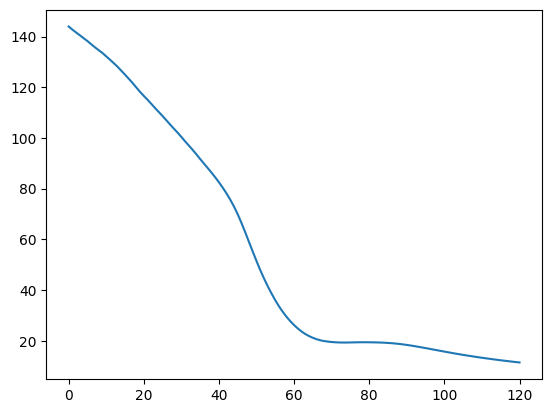

In [16]:
plt.plot(B_mean)

In [12]:
tau = np.copy(cube.tau)
tau = tau.transpose(1,2,0)
print(tau.shape)

rho = np.copy(cube.rho)
rho = rho.transpose(1,2,0)
print(rho.shape)

T = np.copy(cube.Temp)
T = T.transpose(1,2,0)
print(T.shape)

B = (cube.Bx**2 + cube.By**2 + cube.Bz**2)**0.5 * np.sqrt(4.0*np.pi)
B = B.transpose(1,2,0)
print(B.shape)

AttributeError: 'MuramSnap' object has no attribute 'tau'

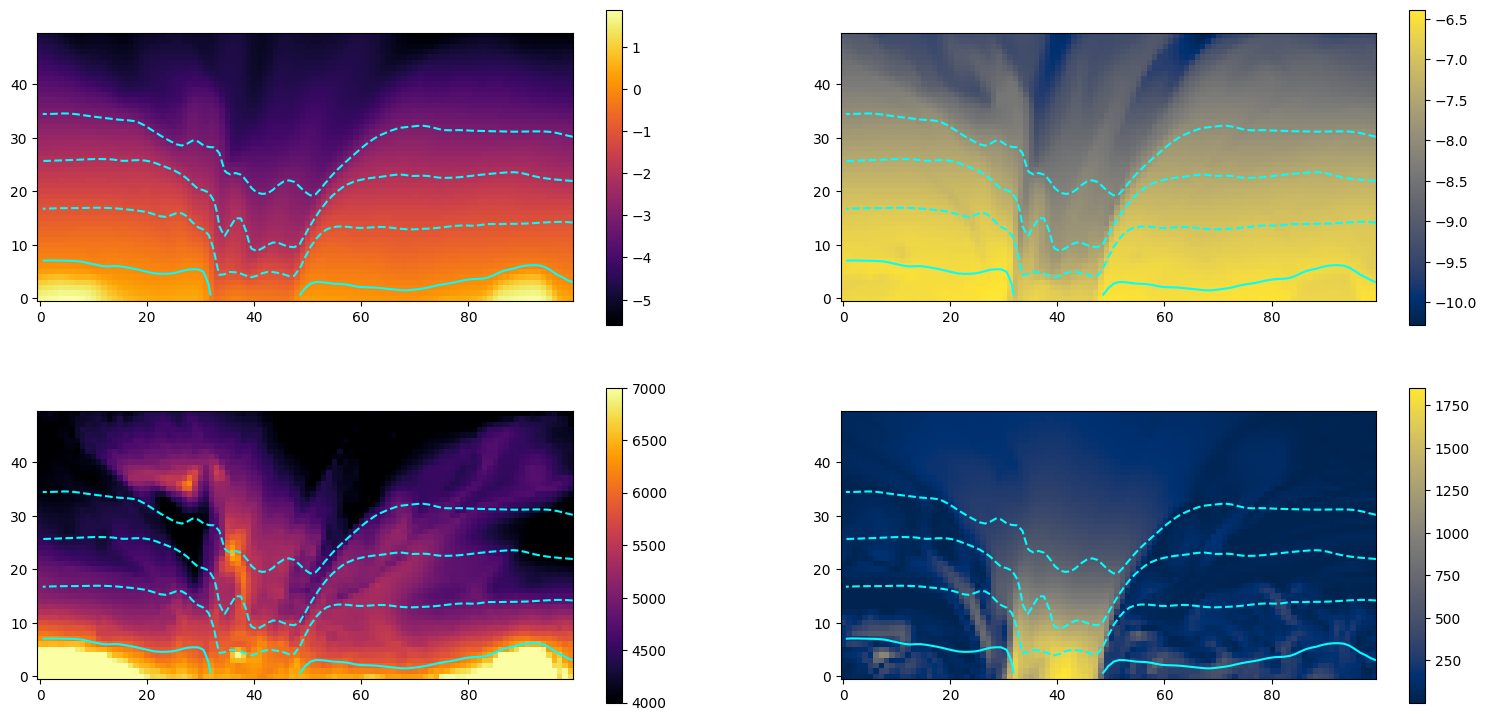

In [38]:
i = 770

# Let's plot the vertical slice of tau values for a given y index and given x and z range

plt.figure(figsize=(19,9))
plt.subplot(221)
plt.imshow(np.log10(tau[i,1230:1330,40:90]).T, origin='lower', cmap='inferno')

plt.colorbar()
# Let's plot some tau = const contours in this slice
levels = [0.001, 0.01, 0.1, 1.0]
plt.contour(np.log10(tau[i,1230:1330,40:90]).T, levels=np.log10(levels), colors='cyan', origin='lower')

plt.subplot(222)
plt.imshow(np.log10(rho[i,1230:1330,40:90]).T, origin='lower', cmap='cividis')

plt.colorbar()
# Let's plot some tau = const contours in this slice
levels = [0.001, 0.01, 0.1, 1.0]
plt.contour(np.log10(tau[i,1230:1330,40:90]).T, levels=np.log10(levels), colors='cyan', origin='lower')

plt.subplot(223)
plt.imshow(T[i,1230:1330,40:90].T, origin='lower', cmap='inferno',vmin=4000, vmax=7000)

plt.colorbar()
# Let's plot some tau = const contours in this slice
levels = [0.001, 0.01, 0.1, 1.0]
plt.contour(np.log10(tau[i,1230:1330,40:90]).T, levels=np.log10(levels), colors='cyan', origin='lower')

plt.subplot(224)
plt.imshow(B[i,1230:1330,40:90].T, origin='lower', cmap='cividis')

plt.colorbar()
# Let's plot some tau = const contours in this slice
levels = [0.001, 0.01, 0.1, 1.0]
plt.contour(np.log10(tau[i,1230:1330,40:90]).T, levels=np.log10(levels), colors='cyan', origin='lower')


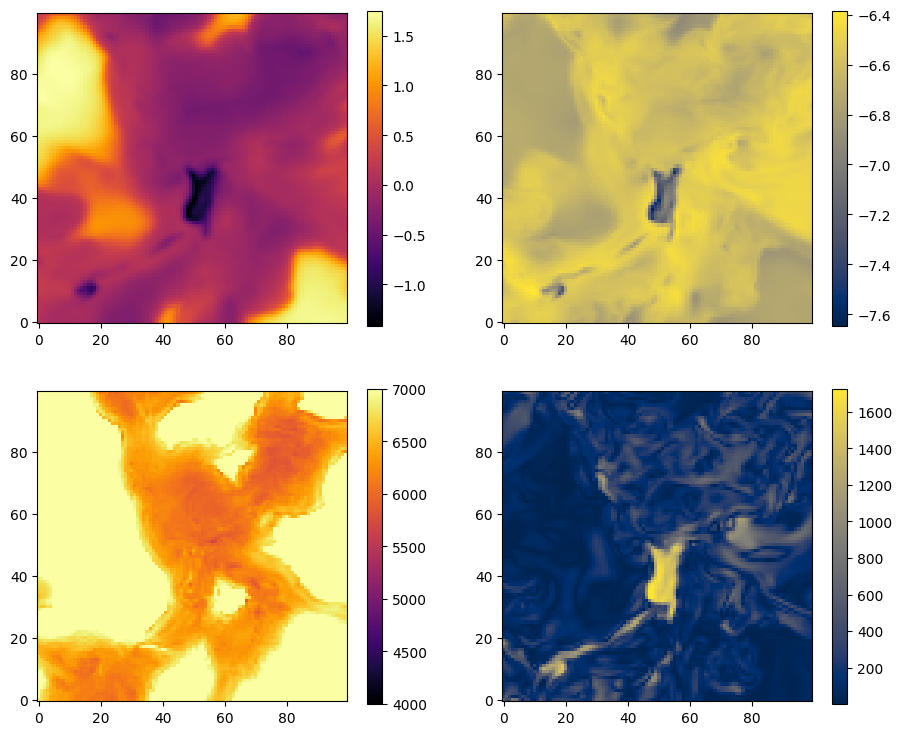

In [45]:
# Let's look how this swirl looks like from the top
z = 45
x_low = 720
x_high = 820
y_low = 1230    
y_high = 1330

# Now plot 4 panels with the same quantities as above, but in x,y:
plt.figure(figsize=(11,9))
plt.subplot(221)
plt.imshow(np.log10(tau[x_low:x_high,y_low:y_high,z]).T, origin='lower', cmap='inferno')
plt.colorbar()

plt.subplot(222)
plt.imshow(np.log10(rho[x_low:x_high,y_low:y_high,z]).T, origin='lower', cmap='cividis')
plt.colorbar() 

plt.subplot(223)
plt.imshow(T[x_low:x_high,y_low:y_high,z-3].T, origin='lower', cmap='inferno',vmin=4000, vmax=7000)
plt.colorbar()

plt.subplot(224)
plt.imshow(B[x_low:x_high,y_low:y_high,z].T, origin='lower', cmap='cividis')
plt.colorbar()


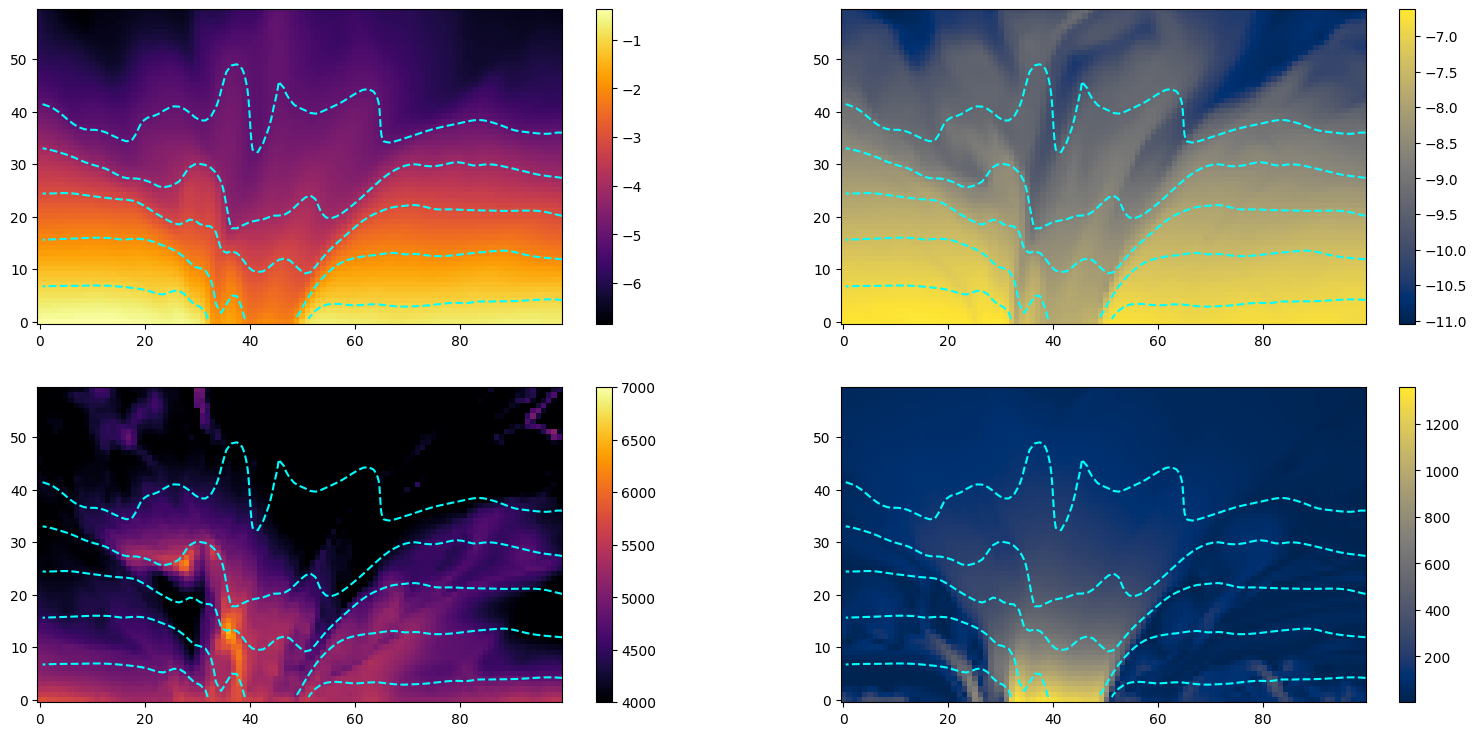

In [41]:
i = 770
z_low = 50
z_high = 110

levels = [1E-5,1E-4,0.001, 0.01, 0.1]

# Let's plot the vertical slice of tau values for a given y index and given x and z range

plt.figure(figsize=(19,9))
plt.subplot(221)
plt.imshow(np.log10(tau[i,1230:1330,z_low:z_high]).T, origin='lower', cmap='inferno')

plt.colorbar()
# Let's plot some tau = const contours in this slice
plt.contour(np.log10(tau[i,1230:1330,z_low:z_high]).T, levels=np.log10(levels), colors='cyan', origin='lower')

plt.subplot(222)
plt.imshow(np.log10(rho[i,1230:1330,z_low:z_high]).T, origin='lower', cmap='cividis')

plt.colorbar()
# Let's plot some tau = const contours in this slice
plt.contour(np.log10(tau[i,1230:1330,z_low:z_high]).T, levels=np.log10(levels), colors='cyan', origin='lower')

plt.subplot(223)
plt.imshow(T[i,1230:1330,z_low:z_high].T, origin='lower', cmap='inferno',vmin=4000, vmax=7000)

plt.colorbar()
# Let's plot some tau = const contours in this slice

plt.contour(np.log10(tau[i,1230:1330,z_low:z_high]).T, levels=np.log10(levels), colors='cyan', origin='lower')

plt.subplot(224)
plt.imshow(B[i,1230:1330,z_low:z_high].T, origin='lower', cmap='cividis')

plt.colorbar()
# Let's plot some tau = const contours in this slice
plt.contour(np.log10(tau[i,1230:1330,z_low:z_high]).T, levels=np.log10(levels), colors='cyan', origin='lower')